# **Import libraries**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

# **Load data**

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\Car Price Prediction\Car Price Prediction\Cars_Data.csv")
df.shape

(77119, 11)

# **Initial inspection**

In [3]:
df.head()

,price,brand,model,color,registration_date,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km.1,mileage_in_km
0,2013796,ford,Kuga,black,01-05-23,140,190,Automatic,Hybrid,5.4,100
1,604557,hyundai,i10,black,01-09-18,49,67,Manual,Petrol,4.6,27782
2,1281316,honda,CR-V,red,01-07-18,114,155,Automatic,Petrol,7.5,57000
3,1830676,kia,Sportage,black,01-02-23,110,150,Manual,Petrol,5.9,7500
4,303456,honda,Civic,black,01-09-09,103,140,Manual,Petrol,6.7,160000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77119 entries, 0 to 77118
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   price                       77119 non-null  int64  
 1   brand                       77119 non-null  object 
 2   model                       77119 non-null  object 
 3   color                       77119 non-null  object 
 4   registration_date           77119 non-null  object 
 5   power_kw                    77119 non-null  int64  
 6   power_ps                    77119 non-null  int64  
 7   transmission_type           77119 non-null  object 
 8   fuel_type                   77119 non-null  object 
 9   fuel_consumption_l_100km.1  77119 non-null  float64
 10  mileage_in_km               77119 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 6.5+ MB


# **Remove duplicates**

In [5]:
df.duplicated().sum()

2674

In [6]:
df = df.drop_duplicates()
df.shape

(74445, 11)

# **Cardinality check**

In [7]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

price: 10206
brand: 29
model: 510
color: 14
registration_date: 331
power_kw: 400
power_ps: 400
transmission_type: 4
fuel_type: 4
fuel_consumption_l_100km.1: 312
mileage_in_km: 28919


# **Parse date → vehicle_age**

In [8]:
df["registration_date"] = pd.to_datetime(
    df["registration_date"],
    format="%d-%m-%y",
    errors="coerce"
)

current_year = datetime.now().year
df["vehicle_age"] = current_year - df["registration_date"].dt.year

df.drop(columns=["registration_date"], inplace=True)

In [9]:
df["vehicle_age"].describe()

count    74445.000000
mean         9.449204
std          4.926856
min          3.000000
25%          6.000000
50%          8.000000
75%         12.000000
max         31.000000
Name: vehicle_age, dtype: float64

# **Logical data cleaning**

In [10]:
df = df[df["mileage_in_km"] > 0]
df = df[df["vehicle_age"] >= 0]
df.shape

(74364, 11)

# **Target distribution (EDA)**

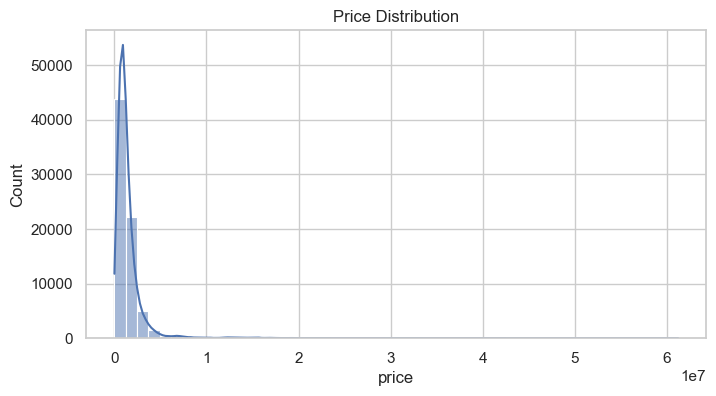

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

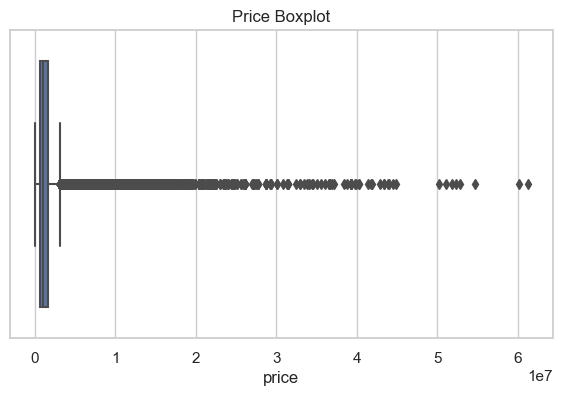

In [12]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["price"])
plt.title("Price Boxplot")
plt.show()

# **Outlier handling (WINSORIZATION, NOT deletion)**

In [13]:
p_low, p_high = df["price"].quantile([0.01, 0.99])
df["price"] = df["price"].clip(p_low, p_high)

In [14]:
p_low, p_high = df["price"].quantile([0.01, 0.99])
df["price"] = df["price"].clip(p_low, p_high)

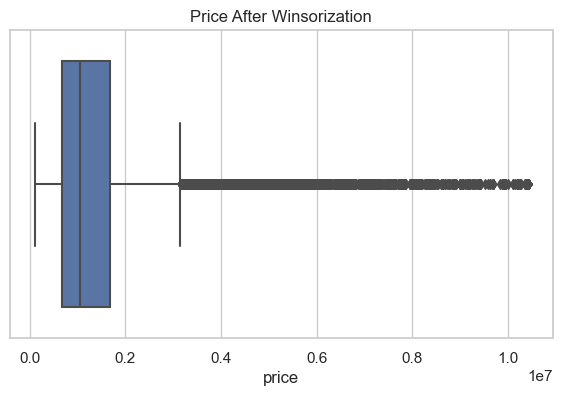

In [15]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["price"])
plt.title("Price After Winsorization")
plt.show()

# **Log-transform target**

In [16]:
df["log_price"] = np.log1p(df["price"])

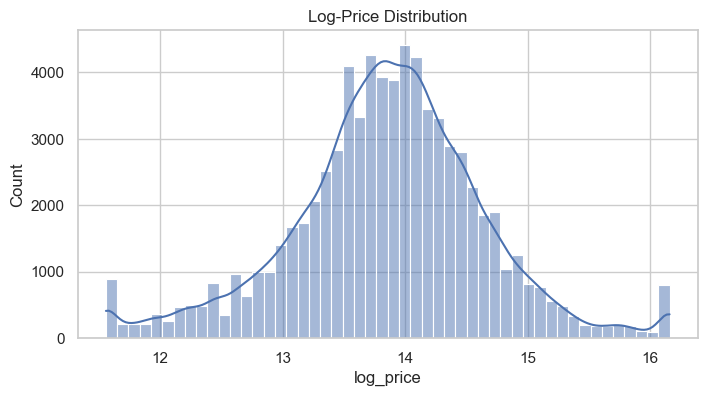

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df["log_price"], bins=50, kde=True)
plt.title("Log-Price Distribution")
plt.show()

# **Power features (remove redundancy)**

In [18]:
df[["power_kw", "power_ps"]].corr()

,power_kw,power_ps
power_kw,1.000000,0.999996
power_ps,0.999996,1.000000


In [19]:
df.drop(columns=["power_kw"], inplace=True)

# **Power features (remove redundancy)**

In [20]:
df["transmission_unknown_flag"] = (df["transmission_type"] == "Unknown").astype(int)

# **Feature engineering**

In [21]:
df["km_per_year"] = df["mileage_in_km"] / (df["vehicle_age"] + 1)
df["log_mileage"] = np.log1p(df["mileage_in_km"])

# **Numerical correlation heatmap (EDA)**

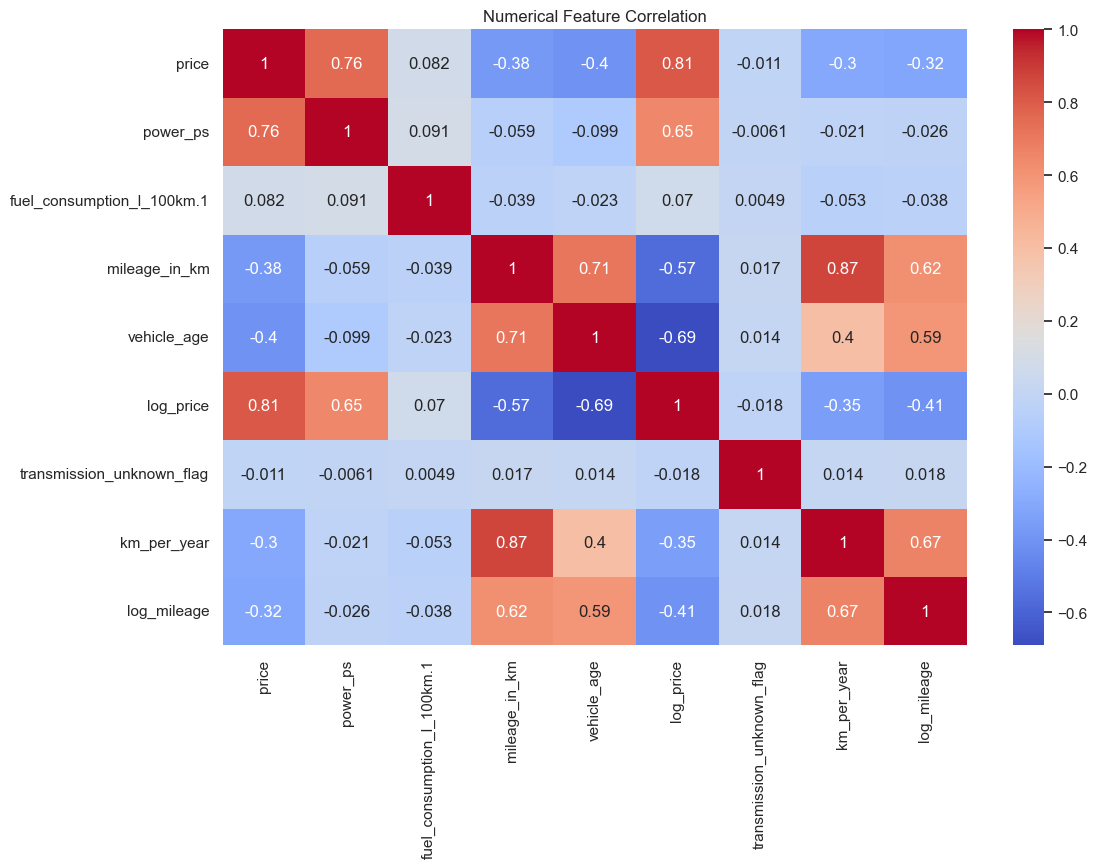

In [22]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),annot=True , cmap="coolwarm")
plt.title("Numerical Feature Correlation")
plt.show()

# **Categorical EDA**

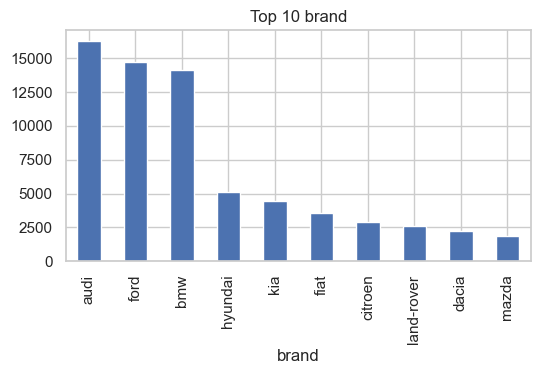

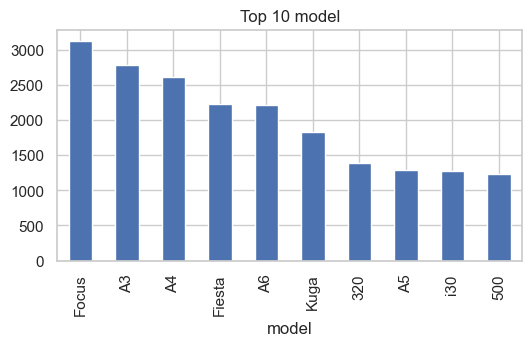

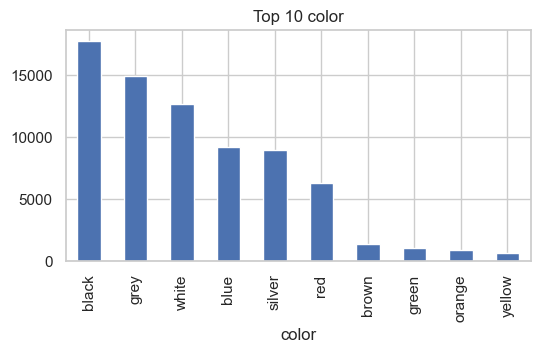

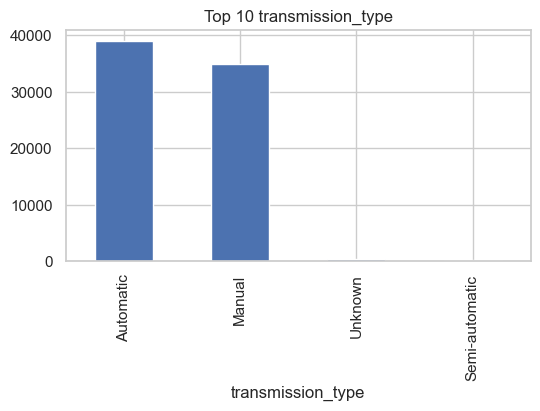

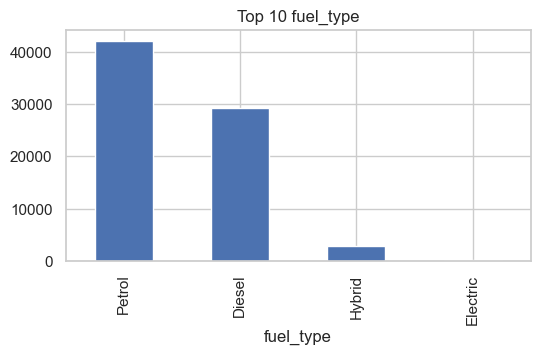

In [23]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top 10 {col}")
    plt.show()

# **Model**

# **Define features & target**

In [24]:
target = "log_price"
X = df.drop(columns=["price", "log_price"])
y = df[target]

In [26]:
cat_cols = [
    "brand",
    "model",
    "color",
    "transmission_type",
    "fuel_type"
]

num_cols = [c for c in X.columns if c not in cat_cols]

# **Train / test split**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Dataset for CatBoost (NO encoding)**

In [27]:
X_train_cat = X_train.copy()
X_test_cat  = X_test.copy()

# **Dataset for sklearn models (One-Hot Encoding)**

In [28]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse=False
)

X_train_cat_enc = encoder.fit_transform(X_train[cat_cols])
X_test_cat_enc  = encoder.transform(X_test[cat_cols])

X_train_sklearn = np.hstack([X_train[num_cols].values, X_train_cat_enc])
X_test_sklearn  = np.hstack([X_test[num_cols].values, X_test_cat_enc])

# **Define models**

In [29]:
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(max_depth=5, random_state=42),
    "SVR": SVR(kernel="rbf"),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(
        silent=True,
        random_seed=42
    )
}

# **Train & evaluate ALL models**

In [30]:
results = []

for name, model in models.items():
    print(f"Training {name}...")

    if name == "CatBoost":
        model.fit(
            X_train_cat,
            y_train,
            cat_features=cat_cols
        )
        y_pred_log = model.predict(X_test_cat)
    else:
        model.fit(X_train_sklearn, y_train)
        y_pred_log = model.predict(X_test_sklearn)

    # back to real price
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_real, y_pred_real),
        "RMSE": np.sqrt(mean_squared_error(y_test_real, y_pred_real)),
        "R2": r2_score(y_test_real, y_pred_real)
    })

print("Training finished.")

Training LinearRegression...
Training DecisionTreeRegressor...
Training SVR...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1859
[LightGBM] [Info] Number of data points in the train set: 59491, number of used features: 311
[LightGBM] [Info] Start training from score 13.849992
Training CatBoost...
Training finished.


# **Results comparison**

In [31]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,Model,MAE,RMSE,R2
5,CatBoost,1.676757e+05,3.438268e+05,9.397368e-01
3,XGBoost,1.776860e+05,3.613936e+05,9.334216e-01
4,LightGBM,1.814433e+05,3.702106e+05,9.301333e-01
1,DecisionTreeRegressor,3.411223e+05,6.392122e+05,7.917128e-01
2,SVR,5.936598e+05,1.237915e+06,2.188145e-01
0,LinearRegression,1.015344e+94,1.200707e+96,-7.349313e+179


# **Best model summary**

In [32]:
best_model = results_df.iloc[0]
best_model

Model         CatBoost
MAE      167675.687507
RMSE     343826.817638
R2            0.939737
Name: 5, dtype: object

# **Final evaluation plot (best model)**

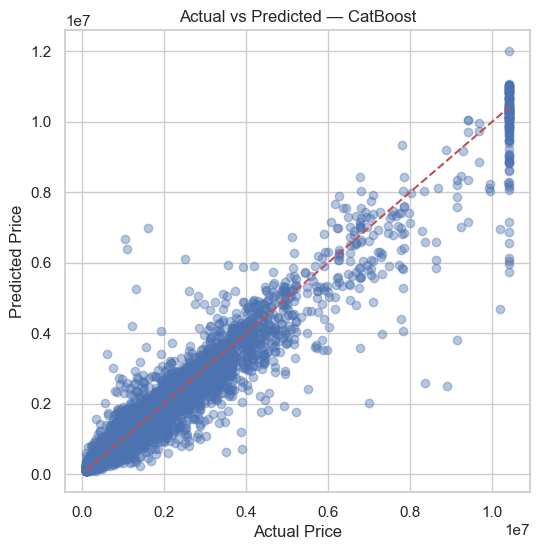

In [33]:
best_name = best_model["Model"]

if best_name == "CatBoost":
    final_model = models["CatBoost"]
    y_pred_log = final_model.predict(X_test_cat)
else:
    final_model = models[best_name]
    y_pred_log = final_model.predict(X_test_sklearn)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.4)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    "--r"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted — {best_name}")
plt.show()

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions are already in log-space
# Convert back to real price scale
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# Metrics
mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, y_pred_real)

print("📊 Final Model Evaluation (Original Price Scale)")
print("-" * 50)
print(f"MAE  (Mean Absolute Error): {mae:,.2f}")
print(f"MSE  (Mean Squared Error):  {mse:,.2f}")
print(f"RMSE (Root MSE):           {rmse:,.2f}")
print(f"R²   (R-squared):          {r2:.4f}")

📊 Final Model Evaluation (Original Price Scale)
--------------------------------------------------
MAE  (Mean Absolute Error): 167,675.69
MSE  (Mean Squared Error):  118,216,880,527.03
RMSE (Root MSE):           343,826.82
R²   (R-squared):          0.9397


# **RandomizedSearchCV for XGBoost**

In [35]:
xgb_param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

xgb_model = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("Tuning XGBoost...")
xgb_search.fit(X_train_sklearn, y_train)

best_xgb = xgb_search.best_estimator_
print("Best XGBoost Params:", xgb_search.best_params_)

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost Params: {'subsample': 0.7, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


# **RandomizedSearchCV for LightGBM**

In [36]:
lgb_param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 10],
    "subsample": [0.7, 0.9, 1.0]
}

lgb_model = LGBMRegressor(
    random_state=42
)

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("Tuning LightGBM...")
lgb_search.fit(X_train_sklearn, y_train)

best_lgb = lgb_search.best_estimator_
print("Best LightGBM Params:", lgb_search.best_params_)

Tuning LightGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1859
[LightGBM] [Info] Number of data points in the train set: 59491, number of used features: 311
[LightGBM] [Info] Start training from score 13.849992
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

# **RandomizedSearchCV for CatBoost**

In [37]:
cat_param_grid = {
    "iterations": [1000, 1500, 2000, 3000],
    "depth": [6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05],
    "l2_leaf_reg": [3, 5, 7],
    "bagging_temperature": [0, 1, 5],
    "random_strength": [5, 10]
}

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="R2",
    random_seed=42,
    silent=True
)

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("Tuning CatBoost...")
cat_search.fit(
    X_train_cat,
    y_train,
    cat_features=cat_cols
)

best_cat = cat_search.best_estimator_
print("Best CatBoost Params:", cat_search.best_params_)

Tuning CatBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CatBoost Params: {'random_strength': 10, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 3000, 'depth': 8, 'bagging_temperature': 0}


# **Final evaluation of tuned models**

In [38]:
final_models = {
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "CatBoost": best_cat
}

final_results = []

for name, model in final_models.items():
    print(f"Evaluating {name}...")

    if name == "CatBoost":
        y_pred_log = model.predict(X_test_cat)
    else:
        y_pred_log = model.predict(X_test_sklearn)

    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    final_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_real, y_pred_real),
        "RMSE": np.sqrt(mean_squared_error(y_test_real, y_pred_real)),
        "R2": r2_score(y_test_real, y_pred_real)
    })

final_results_df = pd.DataFrame(final_results).sort_values("R2", ascending=False)
final_results_df

Evaluating XGBoost...
Evaluating LightGBM...
Evaluating CatBoost...


,Model,MAE,RMSE,R2
2,CatBoost,160115.546783,334327.859950,0.943021
1,LightGBM,160140.879463,336024.426852,0.942441
0,XGBoost,161459.610276,340006.150886,0.941069


# **Train & Test R² for ALL 3 models**

In [ ]:
results_train_test = []

# ---------- CatBoost ----------
y_train_cb = np.expm1(best_cat.predict(X_train_cat))
y_test_cb  = np.expm1(best_cat.predict(X_test_cat))

y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

results_train_test.append({
    "Model": "CatBoost",
    "Train_R2": r2_score(y_train_real, y_train_cb),
    "Test_R2": r2_score(y_test_real, y_test_cb)
})

# ---------- LightGBM ----------
y_train_lgb = np.expm1(best_lgb.predict(X_train_sklearn))
y_test_lgb  = np.expm1(best_lgb.predict(X_test_sklearn))

results_train_test.append({
    "Model": "LightGBM",
    "Train_R2": r2_score(y_train_real, y_train_lgb),
    "Test_R2": r2_score(y_test_real, y_test_lgb)
})

# ---------- XGBoost ----------
y_train_xgb = np.expm1(best_xgb.predict(X_train_sklearn))
y_test_xgb  = np.expm1(best_xgb.predict(X_test_sklearn))

results_train_test.append({
    "Model": "XGBoost",
    "Train_R2": r2_score(y_train_real, y_train_xgb),
    "Test_R2": r2_score(y_test_real, y_test_xgb)
})

train_test_df = pd.DataFrame(results_train_test)
train_test_df

,Model,Train_R2,Test_R2
0,CatBoost,0.953196,0.943021
1,LightGBM,0.953414,0.942441
2,XGBoost,0.957874,0.941069
